# β stabilisation and mode type: GFTM (FILTER=0.5) and TGLF against GS2 (M1_A1_NE, R3, R4)

γ vs β at fixed ky, one figure per code against GS2, for each case. Codes: GFTM widths 0.4 / 0.6 / 0.7 / 0.8
(`scan_beta_f05`, FILTER=0.5) and TGLF default / V5 (`scan_beta_modes`). All scans use GS2's own (ky, β) grid.

**Line styles.** GS2 black (dominant mode only). Code: dominant mode (`argmax` of `growth_rate` over `mode`, never
index 0) solid, the other mode dashed (`NMODES=2`).

**Markers = mode type** from `general_analysis.mode_classification` (cutoffs `T_BAL`, `T_TEAR`, see that module):
▲ MTM (tearing parity), ■ KBM (ballooning parity), ● mixed. Markers are drawn only where γ > 0.
- **GS2** uses all four indicators (tearing parameter T, ω sign, χe/χi, De/χe) from each run's final time.
- **GFTM / TGLF** linear runs have no per-mode flux weights, so they are classified on **T and ω only**, with the
  same cutoffs: KBM = ω>0 and T<`T_BAL`; MTM = ω<0 and T>`T_TEAR`; otherwise mixed. A code marker is therefore a
  looser test than a GS2 one, and "KBM" there means only "ballooning parity, ion direction".
- T for GFTM / TGLF is the `tearing_parameter` stored per mode in each leaf's `pyroscan.nc`.

**β axis.** Code scans store pyrokinetics β (= GS2's number × a per-case factor f); the x axis here is **GS2's β
number**, matched by index. f is printed below and checked constant.

## Imports and settings

In [1]:
from pathlib import Path
import os
import numpy as np
import xarray as xr
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pyrokinetics import Pyro
from pyrokinetics.diagnostics.field_line import FieldLine
from general_analysis import mode_classification as mc

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file() and (path / "notebooks").is_dir()
)
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
load_dotenv(ROOT / "local.env", override=True)

analysis_name = "beta_stabilisation_f05"
data_root = Path(os.environ["GK_DATA_ROOT"]).expanduser()
run_template = "Runs"

cases = ["M1_A1_NE", "R3", "R4"]
ky_targets = [0.1, 0.2, 0.3, 0.5]          # snapped to the nearest GS2 grid value, shown in the panel titles

# GS2 reference: data_root / code / run_template / project / case / scan_information
gs2_code, gs2_project, gs2_scan = "GS2", "scan_beta", "parameter_scan_GS2"
# Codes, one figure each: label -> (code, project, scan_information = leaf). Same three path parts for every case.
codes = {
    "GFTM w0.4": ("GFTM", "scan_beta_f05", "w0p4"),
    "GFTM w0.6": ("GFTM", "scan_beta_f05", "w0p6"),
    "GFTM w0.7": ("GFTM", "scan_beta_f05", "w0p7"),
    "GFTM w0.8": ("GFTM", "scan_beta_f05", "w0p8"),
    "TGLF default": ("TGLF", "scan_beta_modes", "default"),
    "TGLF V5": ("TGLF", "scan_beta_modes", "v5"),
}
deck = {"GFTM": "input.gftm", "TGLF": "input.tglf"}     # per-run input name, only for the marker spot check
gamma_floor = 0.0                                        # markers only where gamma > this
n_spot, seed = 3, 0                                      # spot-check cells per (case, code family)

## Load data

The scan `pyroscan.nc` of every leaf, opened lazily. GS2 and the codes must share the ky grid exactly; nothing is
interpolated.

In [2]:
def scan(code, project, case, leaf):
    return xr.open_dataset(data_root / code / run_template / project / case / leaf / "pyroscan.nc")

gs2 = {c: scan(gs2_code, gs2_project, c, gs2_scan) for c in cases}
model = {(c, lab): scan(code, project, c, leaf) for c in cases for lab, (code, project, leaf) in codes.items()}

for c in cases:
    for lab in codes:
        ds = model[(c, lab)]
        assert np.array_equal(ds.ky.values, gs2[c].ky.values), (c, lab, "ky grid differs from GS2")
        ratio = ds.beta.values / gs2[c].beta.values
        assert np.allclose(ratio, ratio[0], rtol=1e-3), (c, lab, "beta is not GS2 beta x constant")
    print(c, "ky", gs2[c].ky.size, "beta", gs2[c].beta.size, "| pyro beta / GS2 beta f =", round(float(ratio[0]), 4),
          "| modes", {lab: int(model[(c, lab)].mode.size) for lab in codes})

M1_A1_NE ky 40 beta 19 | pyro beta / GS2 beta f = 1.0 | modes {'GFTM w0.4': 2, 'GFTM w0.6': 2, 'GFTM w0.7': 2, 'GFTM w0.8': 2, 'TGLF default': 2, 'TGLF V5': 2}
R3 ky 42 beta 19 | pyro beta / GS2 beta f = 0.9546 | modes {'GFTM w0.4': 2, 'GFTM w0.6': 2, 'GFTM w0.7': 2, 'GFTM w0.8': 2, 'TGLF default': 2, 'TGLF V5': 2}
R4 ky 42 beta 19 | pyro beta / GS2 beta f = 0.8776 | modes {'GFTM w0.4': 2, 'GFTM w0.6': 2, 'GFTM w0.7': 2, 'GFTM w0.8': 2, 'TGLF default': 2, 'TGLF V5': 2}


## Calculate and select

Nearest GS2 ky to each target (actual values printed). GS2 type per plotted (ky, β) cell from the run's own
deck and output, through `mode_classification.indicators` + `classify`. Code type from stored `tearing_parameter` and
`mode_frequency` per mode with the same cutoffs (T and ω only, see header).

In [3]:
ky_index = {c: [int(np.abs(gs2[c].ky.values - k).argmin()) for k in ky_targets] for c in cases}
for c in cases:
    print(c, "ky target -> GS2 grid:", {k: round(float(gs2[c].ky.values[i]), 4) for k, i in zip(ky_targets, ky_index[c])})

def gs2_type(case, ky, beta):
    "GS2 run directory is named from GS2's own ky and beta numbers (3 decimals)"
    d = data_root / gs2_code / run_template / gs2_project / case / gs2_scan / f"ky{ky:.3f}_beta{beta:.3f}"
    pyro = Pyro(gk_file=d / "gs2.in")
    pyro.load_gk_output(load_fields=True, load_fluxes=True)
    return mc.classify(mc.indicators(pyro))

gs2_label = {(c, i, j): gs2_type(c, float(gs2[c].ky[i]), float(gs2[c].beta[j]))
             for c in cases for i in ky_index[c] for j in range(gs2[c].beta.size)
             if gs2[c].growth_rate.values[i, j] > gamma_floor}

def code_type(T, omega):
    "same cutoffs as mode_classification.classify, on the indicators a GFTM/TGLF linear run has"
    w = mc.ION_DIRECTION * omega
    return np.where((w > 0) & (T < mc.T_BAL), "KBM", np.where((w < 0) & (T > mc.T_TEAR), "MTM", "mixed"))

code_label = {k: code_type(ds.tearing_parameter.values, ds.mode_frequency.values) for k, ds in model.items()}
dominant = {k: ds.growth_rate.fillna(-np.inf).argmax("mode").values for k, ds in model.items()}   # (ky, beta)
for c in cases:
    n = {t: sum(1 for k, v in gs2_label.items() if k[0] == c and v == t) for t in ("KBM", "MTM", "mixed")}
    print(c, "GS2 type counts at plotted ky (gamma>0):", n)

M1_A1_NE ky target -> GS2 grid: {0.1: 0.1115, 0.2: 0.1877, 0.3: 0.2892, 0.5: 0.4923}
R3 ky target -> GS2 grid: {0.1: 0.1115, 0.2: 0.2, 0.3: 0.3, 0.5: 0.4923}
R4 ky target -> GS2 grid: {0.1: 0.1115, 0.2: 0.2, 0.3: 0.3, 0.5: 0.4923}


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/pyrokinetics/pyro.py:1792: UserWarning: Explicitly set value of beta (0.01 beta_ref_ee_B0_gs20000) is inconsistent with value from physical reference values (0.036316584746068435 beta_ref_ee_B0_gs20000)
  warnings.warn(


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/pyrokinetics/pyro.py:1792: UserWarning: Explicitly set value of beta (0.02 beta_ref_ee_B0_gs20001) is inconsistent with value from physical reference values (0.036316584746068435 beta_ref_ee_B0_gs20001)
  warnings.warn(


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


...

/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/pyrokinetics/gk_code/gk_output.py:694: UserWarning: Mode frequency may not be accurate due to low temporal resolution
  warnings.warn(
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/pyrokinetics/gk_code/gk_output.py:694: UserWarning: Mode frequency may not be accurate due to low temporal resolution
  warnings.warn(
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/pyrokinetics/gk_code/gk_output.py:694: UserWarning: Mode frequency may not be accurate due to low temporal resolution
  warnings.warn(
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


M1_A1_NE GS2 type counts at plotted ky (gamma>0): {'KBM': 43, 'MTM': 4, 'mixed': 2}
R3 GS2 type counts at plotted ky (gamma>0): {'KBM': 32, 'MTM': 31, 'mixed': 11}
R4 GS2 type counts at plotted ky (gamma>0): {'KBM': 14, 'MTM': 13, 'mixed': 8}


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/pyrokinetics/gk_code/gk_output.py:694: UserWarning: Mode frequency may not be accurate due to low temporal resolution
  warnings.warn(
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


## Plot

One figure per (case, code): four ky panels, γ vs GS2-β. Markers: ▲ MTM, ■ KBM, ● mixed.

In [4]:
marker = {"MTM": "^", "KBM": "s", "mixed": "o"}
key = [Line2D([], [], color="k", label="GS2 (dominant)"),
       Line2D([], [], color="C0", ls="-", label="code, dominant mode"),
       Line2D([], [], color="C0", ls="--", label="code, other mode"),
       *[Line2D([], [], color="grey", ls="", marker=m, label=t) for t, m in marker.items()]]
figs = {}
for c in cases:
    ref, beta = gs2[c], gs2[c].beta.values
    for lab in codes:
        ds, dom, typ = model[(c, lab)], dominant[(c, lab)], code_label[(c, lab)]
        fig, axes = plt.subplots(1, len(ky_targets), figsize=(4 * len(ky_targets), 3.6), sharey=True)
        for ax, i in zip(axes, ky_index[c]):
            ax.plot(beta, ref.growth_rate.values[i], color="k", marker="none")
            for j, g in enumerate(ref.growth_rate.values[i]):
                if (c, i, j) in gs2_label:
                    ax.plot(beta[j], g, color="k", marker=marker[gs2_label[(c, i, j)]], ls="")
            for m in range(ds.mode.size):
                g = ds.growth_rate.values[i, :, m]
                ax.plot(beta, g, color="C0", ls="-" if m == 0 else "--", marker="none")
            for j in range(beta.size):
                for m in range(ds.mode.size):
                    g = ds.growth_rate.values[i, j, m]
                    if g > gamma_floor:
                        ax.plot(beta[j], g, color="C0", marker=marker[typ[i, j, m]], ls="", mfc="C0" if m == dom[i, j] else "none")
            ax.set(xlabel=r"GS2 $\beta$", title=f"ky = {float(ref.ky[i]):.3f} (target {ky_targets[list(ky_index[c]).index(i)]})")
        axes[0].set_ylabel(r"$\gamma$ [$c_s/a$]")
        axes[-1].legend(handles=key, loc="best", fontsize=8)
        fig.suptitle(f"{c}: {lab} vs GS2. Dominant = solid line, filled marker; other mode dashed, open marker", y=1.04)
        figs[(c, lab)] = fig
        plt.close(fig)
print(len(figs), "figures")

18 figures


## Save

In [5]:
output_dir = ROOT / "Plots" / analysis_name
output_dir.mkdir(parents=True, exist_ok=True)
for (c, lab), fig in figs.items():
    fig.savefig(output_dir / f"{c}_{lab.replace(' ', '_').replace('.', 'p')}.png", dpi=150, bbox_inches="tight")
print("saved", len(figs), "to", output_dir)

saved 18 to /pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/Plots/beta_stabilisation_f05


## Marker spot check

For each (case, code family) three random plotted cells (seed above, gamma > 0). Code families: GFTM (4 widths pooled)
and TGLF (2 pooled). **Code cells**: T is recomputed from the run's own deck with pyro's
`FieldLine.compute_linear_tearing_parameter` and compared with the stored value and the marker type. **GS2 cells**: the
full indicator set is shown with the label it produced.

In [6]:
rng = np.random.default_rng(seed)

def code_run_dir(case, lab, i, j):
    code, project, leaf = codes[lab]
    ds = model[(case, lab)]
    return (data_root / code / run_template / project / case / leaf /
            f"ky_{float(ds.ky[i]):.3f}" / f"beta_{float(ds.beta[j]):.3f}"), deck[code]

print("CODE cells: stored T vs recomputed T per mode, omega, label")
for c in cases:
    for family in ("GFTM", "TGLF"):
        labs = [l for l in codes if l.startswith(family)]
        cand = [(l, i, j, m) for l in labs for i in ky_index[c] for j in range(gs2[c].beta.size)
                for m in range(model[(c, l)].mode.size) if model[(c, l)].growth_rate.values[i, j, m] > gamma_floor]
        for k in rng.choice(len(cand), n_spot, replace=False):
            lab, i, j, m = cand[k]
            d, name = code_run_dir(c, lab, i, j)
            pyro = Pyro(gk_file=d / name)
            pyro.load_gk_output(load_fields=True, load_fluxes=False)
            T_new = float(np.asarray(FieldLine(pyro).compute_linear_tearing_parameter()).squeeze()[m])
            ds = model[(c, lab)]
            print(f"{c:9s} {lab:13s} ky={float(ds.ky[i]):.3f} beta_gs2={float(gs2[c].beta[j]):.2f} mode{m}"
                  f"  T stored {float(ds.tearing_parameter.values[i, j, m]):.4f} recomputed {T_new:.4f}"
                  f"  omega {float(ds.mode_frequency.values[i, j, m]):+.3f}  marker {code_label[(c, lab)][i, j, m]}")

print("GS2 cells: T, omega, chi_e/chi_i, De/chi_e -> label")
for c in cases:
    cand = [k for k in gs2_label if k[0] == c]
    for k in rng.choice(len(cand), n_spot, replace=False):
        _, i, j = cand[k]
        d = data_root / gs2_code / run_template / gs2_project / c / gs2_scan / f"ky{float(gs2[c].ky[i]):.3f}_beta{float(gs2[c].beta[j]):.3f}"
        pyro = Pyro(gk_file=d / "gs2.in")
        pyro.load_gk_output(load_fields=True, load_fluxes=True)
        ind = mc.indicators(pyro)
        print(f"{c:9s} GS2 ky={float(gs2[c].ky[i]):.3f} beta={float(gs2[c].beta[j]):.2f}  "
              + "  ".join(f"{n} {ind[n]:+.3f}" for n in ("T", "omega", "chi_ratio", "de_chi")) + f"  -> {mc.classify(ind)}")

CODE cells: stored T vs recomputed T per mode, omega, label


M1_A1_NE  GFTM w0.7     ky=0.289 beta_gs2=0.09 mode0  T stored 0.0000 recomputed 0.0000  omega +2.638  marker KBM


M1_A1_NE  GFTM w0.7     ky=0.112 beta_gs2=0.10 mode1  T stored 0.0000 recomputed 0.0000  omega +0.322  marker KBM


M1_A1_NE  GFTM w0.8     ky=0.188 beta_gs2=0.13 mode1  T stored 0.0000 recomputed 0.0000  omega +1.036  marker KBM


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/backends/api.py:651: RuntimeWarning: 'netcdf4' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/backends/api.py:651: RuntimeWarning: 'scipy' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/backends/api.py:651: RuntimeWarning: 'h5netcdf' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)


...

R4        GS2 ky=0.112 beta=0.01  T +0.000  omega -0.094  chi_ratio +1.432  de_chi +0.544  -> mixed


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/pyrokinetics/gk_code/gk_output.py:694: UserWarning: Mode frequency may not be accurate due to low temporal resolution
  warnings.warn(
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


R4        GS2 ky=0.492 beta=0.19  T +0.654  omega -2.538  chi_ratio +117.645  de_chi +0.006  -> MTM


R4        GS2 ky=0.200 beta=0.02  T +0.000  omega +0.014  chi_ratio +1.086  de_chi +0.640  -> KBM


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


## Interpretation

Left to the reader. Code-side markers use T and ω only (no flux weights), GS2 markers use all four indicators, so a
GS2 "mixed" next to a code "KBM" can be a difference in the test rather than in the physics.

## R4 at high β: why GFTM predicts a strong KBM where GS2 is near marginal (Fusion_PhD-38e9.9)

Above β ≈ 0.07 (GS2 number) GS2's dominant R4 mode at ky ≈ 0.1–0.3 is near marginal, while every GFTM width
predicts a growing ballooning-parity mode, more strongly the larger WIDTH is. This section compares the two at the
level of the mode itself. All reads are pyro objects: each leaf's `pyroscan.nc` through `PyroScanGKOutput`, with
pyro's `Extent` (95% of ∫|field|²dθ) added; per-run `Pyro` loads only for GS2 indicators, GS2 γ(t), GFTM T at WIDTH
1.74 (that leaf stores no `tearing_parameter`), and the β′ check. Dominant mode = `argmax` of γ over `mode`.

Leaves: GFTM `scan_beta_f05/R4/w0p{4,6,7,8}` (FILTER 0.5) and `scan_beta/R4/parameter_scan_gftm_default`
(WIDTH 1.74, otherwise the same deck: FIND_WIDTH=F, FILTER 0.5, NBASIS_MAX 12, NXGRID 32, NMODES 2, USE_BPAR=T).
The 1.74 leaf labels β with GS2's number and ky to 3 decimals; it is matched by index (asserted below).
GS2 convergence: `growth_rate_tolerance` from GS2's `pyroscan.nc`, thresholds from Fusion_PhD-6vvq
(< 1e-2 converged, ≥ 1e-1 unconverged; unconverged GS2 points are drawn open).

In [7]:
from pyrokinetics.pyroscan import PyroScanGKOutput
from pyrokinetics.diagnostics.extent import Extent
from matplotlib.ticker import StrMethodFormatter
import pandas as pd

r4 = "R4"
r4_codes = {   # label -> (code, project, leaf, WIDTH)
    "GFTM w0.4": ("GFTM", "scan_beta_f05", "w0p4", 0.4),
    "GFTM w0.6": ("GFTM", "scan_beta_f05", "w0p6", 0.6),
    "GFTM w0.7": ("GFTM", "scan_beta_f05", "w0p7", 0.7),
    "GFTM w0.8": ("GFTM", "scan_beta_f05", "w0p8", 0.8),
    "GFTM w1.74": ("GFTM", "scan_beta", "parameter_scan_gftm_default", 1.74),
}
r4_eig = ["GFTM w0.4", "GFTM w0.8", "GFTM w1.74"]   # widths drawn in the eigenfunction figures
r4_ky = [0.1, 0.2, 0.3]                            # snapped to GS2's grid
beta_high, beta_low = 0.15, 0.02                   # GS2 beta numbers: the high-beta cells and the control
tol_unconverged = 1e-1
fraction = 0.95
fields = ["phi", "apar", "bpar"]
field_label = {"phi": r"$\phi$", "apar": r"$A_\parallel$", "bpar": r"$B_\parallel$"}
colour = {lab: plt.cm.viridis(x) for lab, x in zip(r4_codes, np.linspace(0, 0.9, len(r4_codes)))}


def v(da):
    return np.asarray(getattr(da.data, "magnitude", da.data))


def load_r4(code, project, leaf):
    out = PyroScanGKOutput.from_netcdf(data_root / code / run_template / project / r4 / leaf / "pyroscan.nc")
    Extent(out, fraction=fraction)
    return out.data


R = {"GS2": load_r4(gs2_code, gs2_project, gs2_scan)}
R |= {lab: load_r4(*spec[:3]) for lab, spec in r4_codes.items()}
for lab, d in R.items():
    assert np.allclose(v(d.ky), v(R["GS2"].ky), atol=1e-3) and d.beta.size == R["GS2"].beta.size, lab


def dominant(d, name):
    "variable of the dominant (argmax gamma over mode) mode; GS2 has one mode"
    if "mode" not in d[name].dims:
        return d[name]
    m = np.nan_to_num(v(d.growth_rate), nan=-np.inf).argmax(-1)
    return d[name].isel(mode=xr.DataArray(m, dims=("ky", "beta")))


beta_r4 = gs2[r4].beta.values            # GS2's numbers, the x axis throughout
iky = [int(np.abs(gs2[r4].ky.values - k).argmin()) for k in r4_ky]
jhi, jlo = (int(np.abs(beta_r4 - b).argmin()) for b in (beta_high, beta_low))
tol = v(R["GS2"].growth_rate_tolerance)
print("ky:", [round(float(gs2[r4].ky[i]), 3) for i in iky], "| beta high", beta_r4[jhi], "control", beta_r4[jlo])

ky: [0.112, 0.2, 0.3] | beta high 0.15 control 0.02


### Where GFTM over-predicts

Dominant γ per code at the plotted ky for β ≥ 0.07, with GS2's tolerance. The eigenfunction cells are the high-β
cells at ky ≈ 0.11 and 0.2 and the low-β control at ky ≈ 0.2, where the codes agree.

In [8]:
g = {lab: v(dominant(d, "growth_rate")) for lab, d in R.items()}
rows = [{"ky": round(float(gs2[r4].ky[i]), 3), "beta": beta_r4[j], "GS2 tol": tol[i, j],
         **{lab: g[lab][i, j] for lab in R}} for i in iky for j in range(beta_r4.size) if beta_r4[j] >= 0.07]
with pd.option_context("display.float_format", "{:.3g}".format, "display.width", 200):
    print(pd.DataFrame(rows).to_string(index=False))

cells = {"control": (iky[1], jlo), "high, ky 0.11": (iky[0], jhi), "high, ky 0.2": (iky[1], jhi)}
for name, (i, j) in cells.items():
    print(f"{name}: ky {float(gs2[r4].ky[i]):.3f} beta {beta_r4[j]:.2f}  " + "  ".join(f"{lab} {g[lab][i, j]:+.3f}" for lab in R))

   ky  beta  GS2 tol      GS2  GFTM w0.4  GFTM w0.6  GFTM w0.7  GFTM w0.8  GFTM w1.74
0.112  0.07     1.06 -0.00781     0.0284     0.0532     0.0934      0.104       0.579
0.112  0.08      1.1 -0.00202     0.0264     0.0864      0.116      0.226       0.642
0.112  0.09     1.06 -0.00682     0.0283      0.104      0.184      0.301         0.7
0.112   0.1      1.9 -0.00263     0.0281      0.117      0.255      0.391       0.752
0.112  0.11     1.09 -0.00191     0.0494      0.156      0.334       0.49       0.798
0.112  0.12     1.19  -0.0057     0.0548      0.222      0.428      0.584       0.837
0.112  0.13     1.09 -0.00325     0.0397      0.294      0.521      0.665        0.87
0.112  0.14     1.23  0.00263     0.0434       0.39      0.606      0.735       0.898
0.112  0.15     1.57  0.00748     0.0407       0.48       0.68      0.793       0.921
0.112  0.16     1.91   0.0105     0.0937      0.561      0.745      0.842        0.94
0.112  0.17     3.08    0.013      0.127      0.634   

### (1) Eigenfunctions

Dominant mode of each code. Every field is divided by the complex φ at |φ|'s peak, so φ is real and 1 there and
A∥, B∥ keep their amplitude and phase relative to φ. Phase is drawn only where |field| > 1% of its own peak.

/tmp/ipykernel_100698/2899336431.py:33: UserWarning: The figure layout has changed to tight
  fig_eig.tight_layout()
/tmp/ipykernel_100698/2899336431.py:34: UserWarning: The figure layout has changed to tight
  fig_ph.tight_layout()


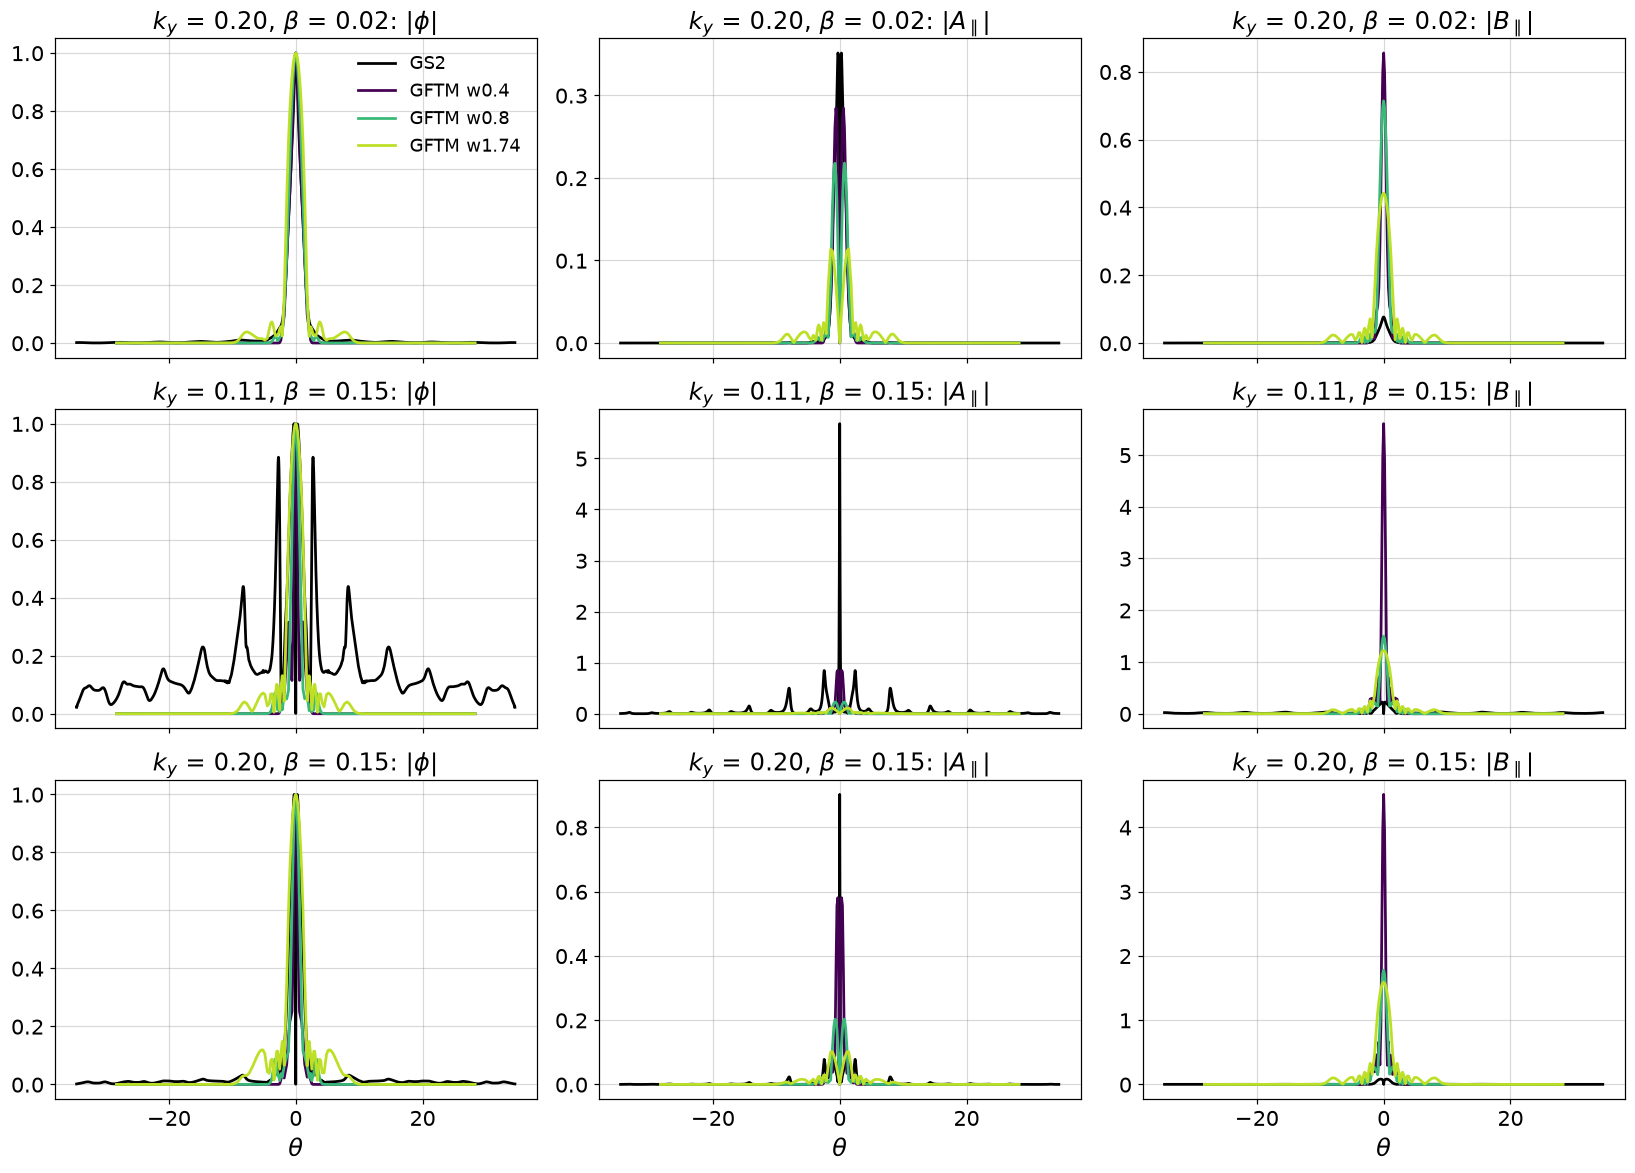

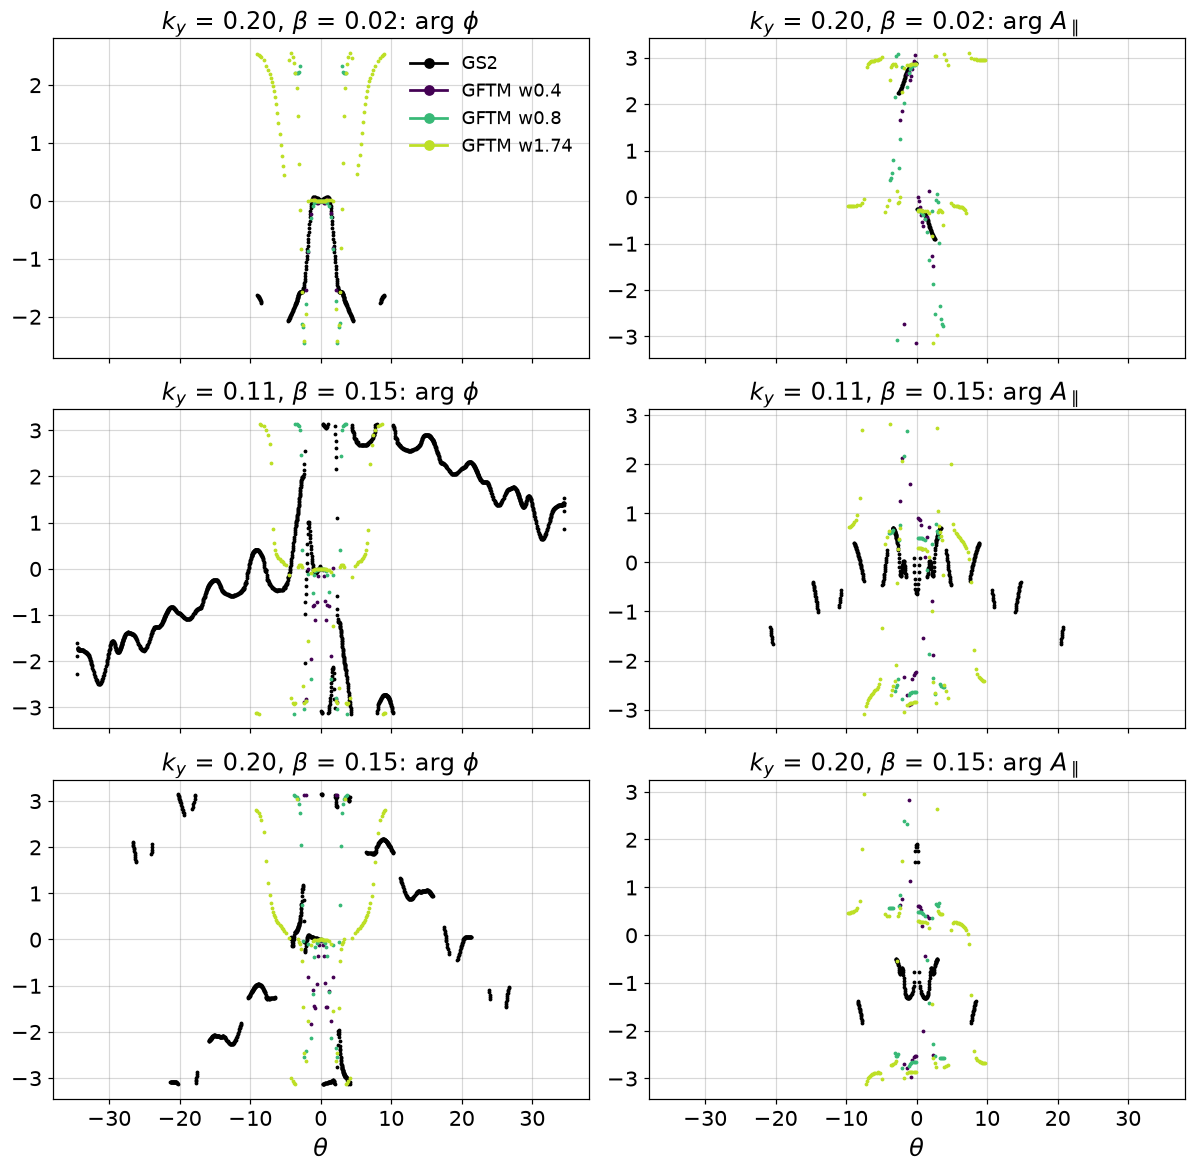

In [9]:
def eig(d, i, j):
    e = dominant(d, "eigenfunctions").isel(ky=i, beta=j)
    f = {k: v(e.sel(field=k)) for k in fields}
    p = f["phi"]
    norm = p[np.nanargmax(np.abs(p))]
    return v(e.theta), {k: x / norm for k, x in f.items()}


r4_eig_codes = ["GS2", *r4_eig]
line_colour = {"GS2": "k", **colour}
fig_eig, axes = plt.subplots(len(cells), len(fields), figsize=(15, 3.6 * len(cells)), sharex=True)
fig_ph, axes_ph = plt.subplots(len(cells), 2, figsize=(11, 3.6 * len(cells)), sharex=True)
for row, (name, (i, j)) in enumerate(cells.items()):
    for lab in r4_eig_codes:
        th, f = eig(R[lab], i, j)
        for col, k in enumerate(fields):
            axes[row, col].plot(th, np.abs(f[k]), color=line_colour[lab], label=lab, marker="none")
        for col, k in enumerate(("phi", "apar")):
            a = np.abs(f[k])
            ok = a > 0.01 * np.nanmax(a)
            axes_ph[row, col].plot(th[ok], np.angle(f[k][ok]), color=line_colour[lab], ls="", marker=".", ms=3)
    title = rf"$k_y$ = {float(gs2[r4].ky[i]):.2f}, $\beta$ = {beta_r4[j]:.2f}"
    for col, k in enumerate(fields):
        axes[row, col].set_title(f"{title}: |{field_label[k]}|", fontsize=16)
    for col, k in enumerate(("phi", "apar")):
        axes_ph[row, col].set_title(f"{title}: arg {field_label[k]}", fontsize=16)
for ax in [*axes.flat, *axes_ph.flat]:
    ax.tick_params(labelsize=14)
for ax in [*axes[-1], *axes_ph[-1]]:
    ax.set_xlabel(r"$\theta$", fontsize=16)
axes[0, 0].legend(fontsize=12)
axes_ph[0, 0].legend(handles=[Line2D([], [], color=line_colour[l], label=l) for l in r4_eig_codes], fontsize=12)
fig_eig.tight_layout()
fig_ph.tight_layout()
plt.show()

### (2) Extents vs β

pyro `Extent` (θ range holding 95% of ∫|field|²dθ) of the dominant mode. Top: the extents themselves (grey dotted =
GS2's θ box, 2 × 34.6 rad; GFTM's wavefunction grid is ±28.3 rad). Bottom: log(Extent Ratio) = log₂(GFTM / GS2).

/tmp/ipykernel_100698/488973952.py:32: UserWarning: The figure layout has changed to tight
  fig_ext.tight_layout()
/tmp/ipykernel_100698/488973952.py:33: UserWarning: The figure layout has changed to tight
  fig_rat.tight_layout()


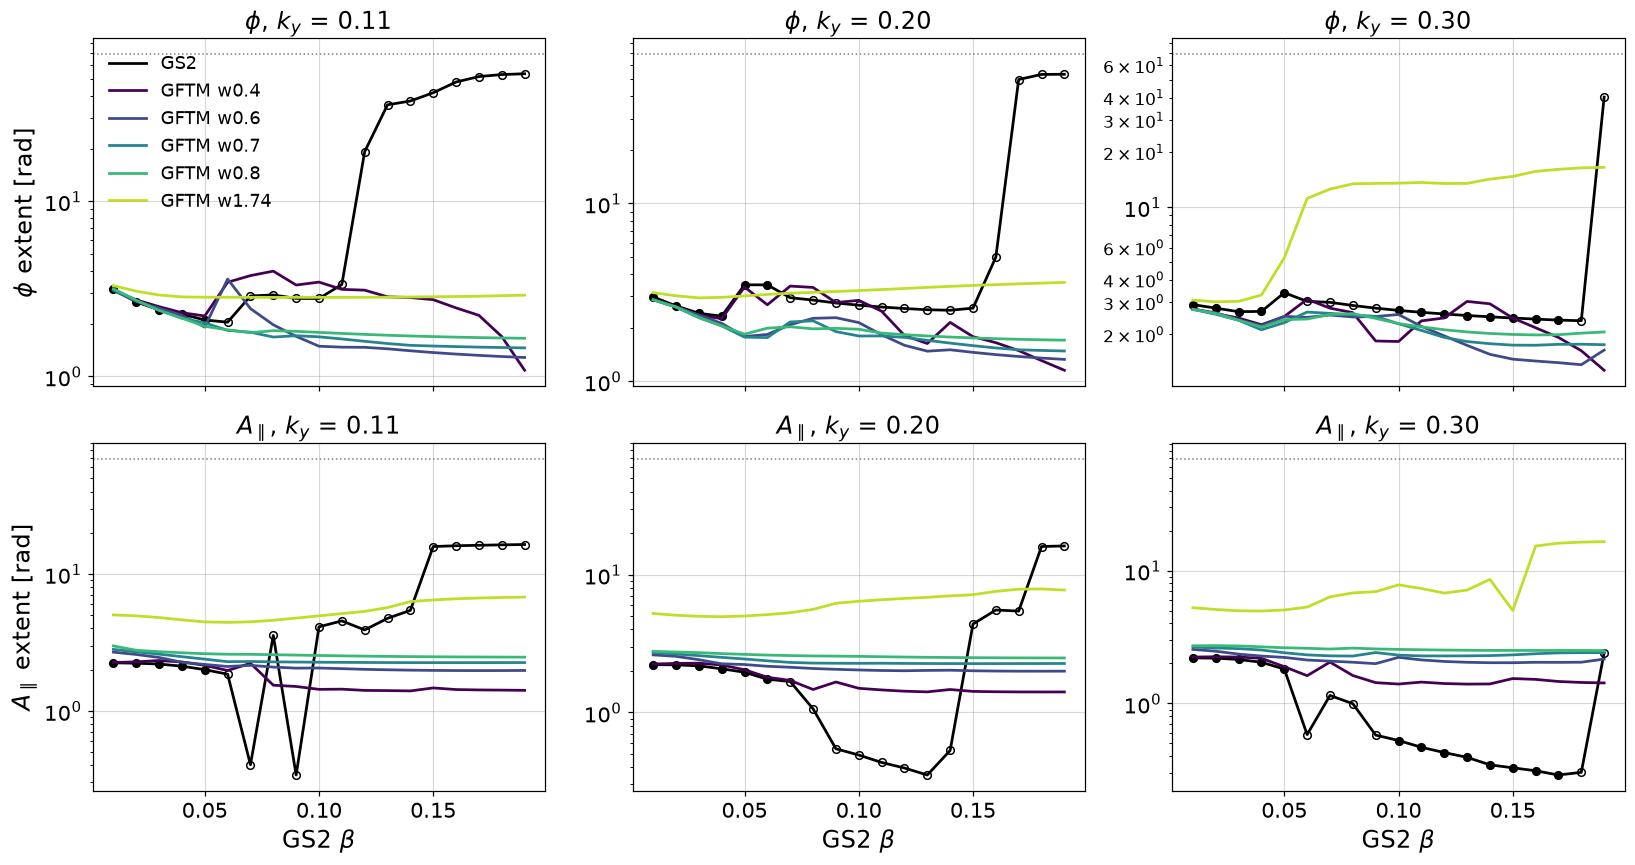

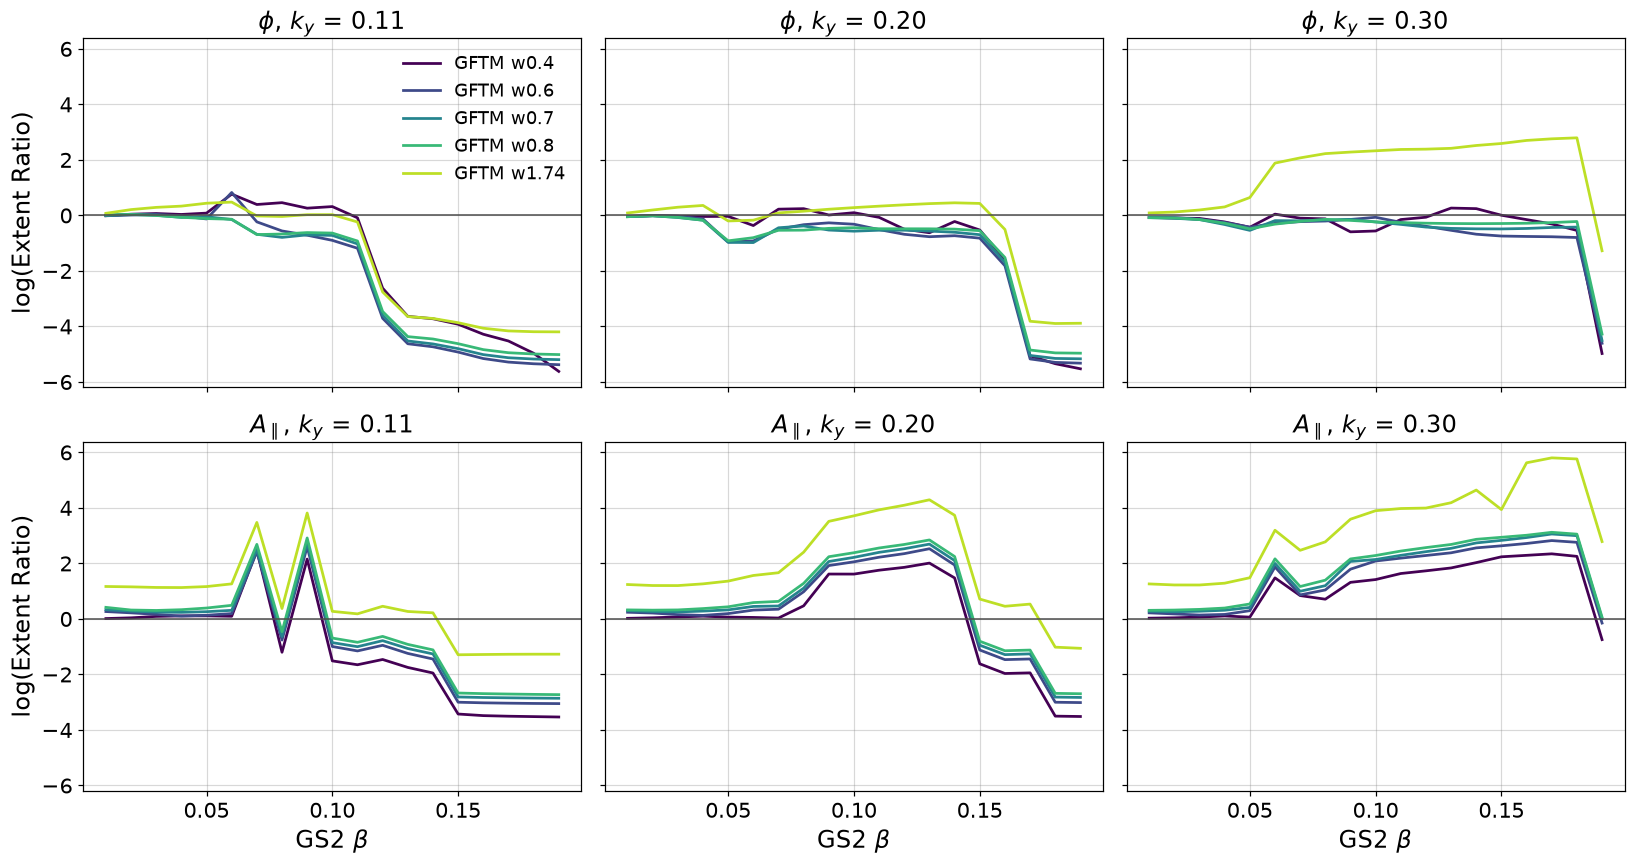

In [10]:
ext = {lab: {k: v(dominant(d, "extent").sel(field=k)) for k in ("phi", "apar")} for lab, d in R.items()}
box = float(np.ptp(v(R["GS2"].theta)))
unconv = tol >= tol_unconverged

fig_ext, axes = plt.subplots(2, len(iky), figsize=(5 * len(iky), 8), sharex=True)
fig_rat, axes_r = plt.subplots(2, len(iky), figsize=(5 * len(iky), 8), sharex=True, sharey=True)
for col, i in enumerate(iky):
    for row, k in enumerate(("phi", "apar")):
        ax, axr = axes[row, col], axes_r[row, col]
        e2 = ext["GS2"][k][i]
        ax.plot(beta_r4, e2, color="k", label="GS2", marker="none")
        ax.plot(beta_r4[~unconv[i]], e2[~unconv[i]], color="k", ls="", marker="o", ms=5)
        ax.plot(beta_r4[unconv[i]], e2[unconv[i]], color="k", ls="", marker="o", ms=5, mfc="none")
        for lab in r4_codes:
            ax.plot(beta_r4, ext[lab][k][i], color=colour[lab], label=lab, marker="none")
            axr.plot(beta_r4, np.log2(ext[lab][k][i] / e2), color=colour[lab], label=lab, marker="none")
        ax.axhline(box, color="0.5", ls=":", lw=1, marker="")
        axr.axhline(0, color="0.3", lw=1, marker="")
        ax.set_yscale("log")
        ax.set_title(rf"{field_label[k]}, $k_y$ = {float(gs2[r4].ky[i]):.2f}", fontsize=16)
        axr.set_title(rf"{field_label[k]}, $k_y$ = {float(gs2[r4].ky[i]):.2f}", fontsize=16)
for a in (axes, axes_r):
    for ax in a.flat:
        ax.tick_params(labelsize=14)
    for ax in a[-1]:
        ax.set_xlabel(r"GS2 $\beta$", fontsize=16)
for row, k in enumerate(("phi", "apar")):
    axes[row, 0].set_ylabel(f"{field_label[k]} extent [rad]", fontsize=16)
    axes_r[row, 0].set_ylabel("log(Extent Ratio)", fontsize=16)
axes[0, 0].legend(fontsize=12)
axes_r[0, 0].legend(fontsize=12)
fig_ext.tight_layout()
fig_rat.tight_layout()
plt.show()

### (3) γ, ω, T and mode type vs β

Dominant mode per code. GS2 indicators from each run (`mode_classification.indicators` + `classify`, full
criteria); code type from T and ω only (`code_type` above). Current cutoffs are printed. Markers where γ > 0:
▲ MTM, ■ KBM, ● mixed; GS2 open = unconverged (tol ≥ 0.1). TGLF default / V5 in grey for context (no markers).
GFTM WIDTH 1.74 has no stored `tearing_parameter`, so its T is computed per run with pyro's
`FieldLine.compute_linear_tearing_parameter` (the function that wrote the stored values for the other leaves).

cutoffs: T_BAL 0.05 T_TEAR 0.15 CHI_KBM (0.25, 4.0)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


...

/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/pyrokinetics/gk_code/gk_output.py:694: UserWarning: Mode frequency may not be accurate due to low temporal resolution
  warnings.warn(
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/pyrokinetics/gk_code/gk_output.py:694: UserWarning: Mode frequency may not be accurate due to low temporal resolution
  warnings.warn(
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/pyrokinetics/gk_code/gk_output.py:694: UserWarning: Mode frequency may not be accurate due to low temporal resolution
  warnings.warn(
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/tmp/ipykernel_100698/3108439787.py:63: UserWarning: The figure layout has changed to tight
  fig_gwt.tight_layout()


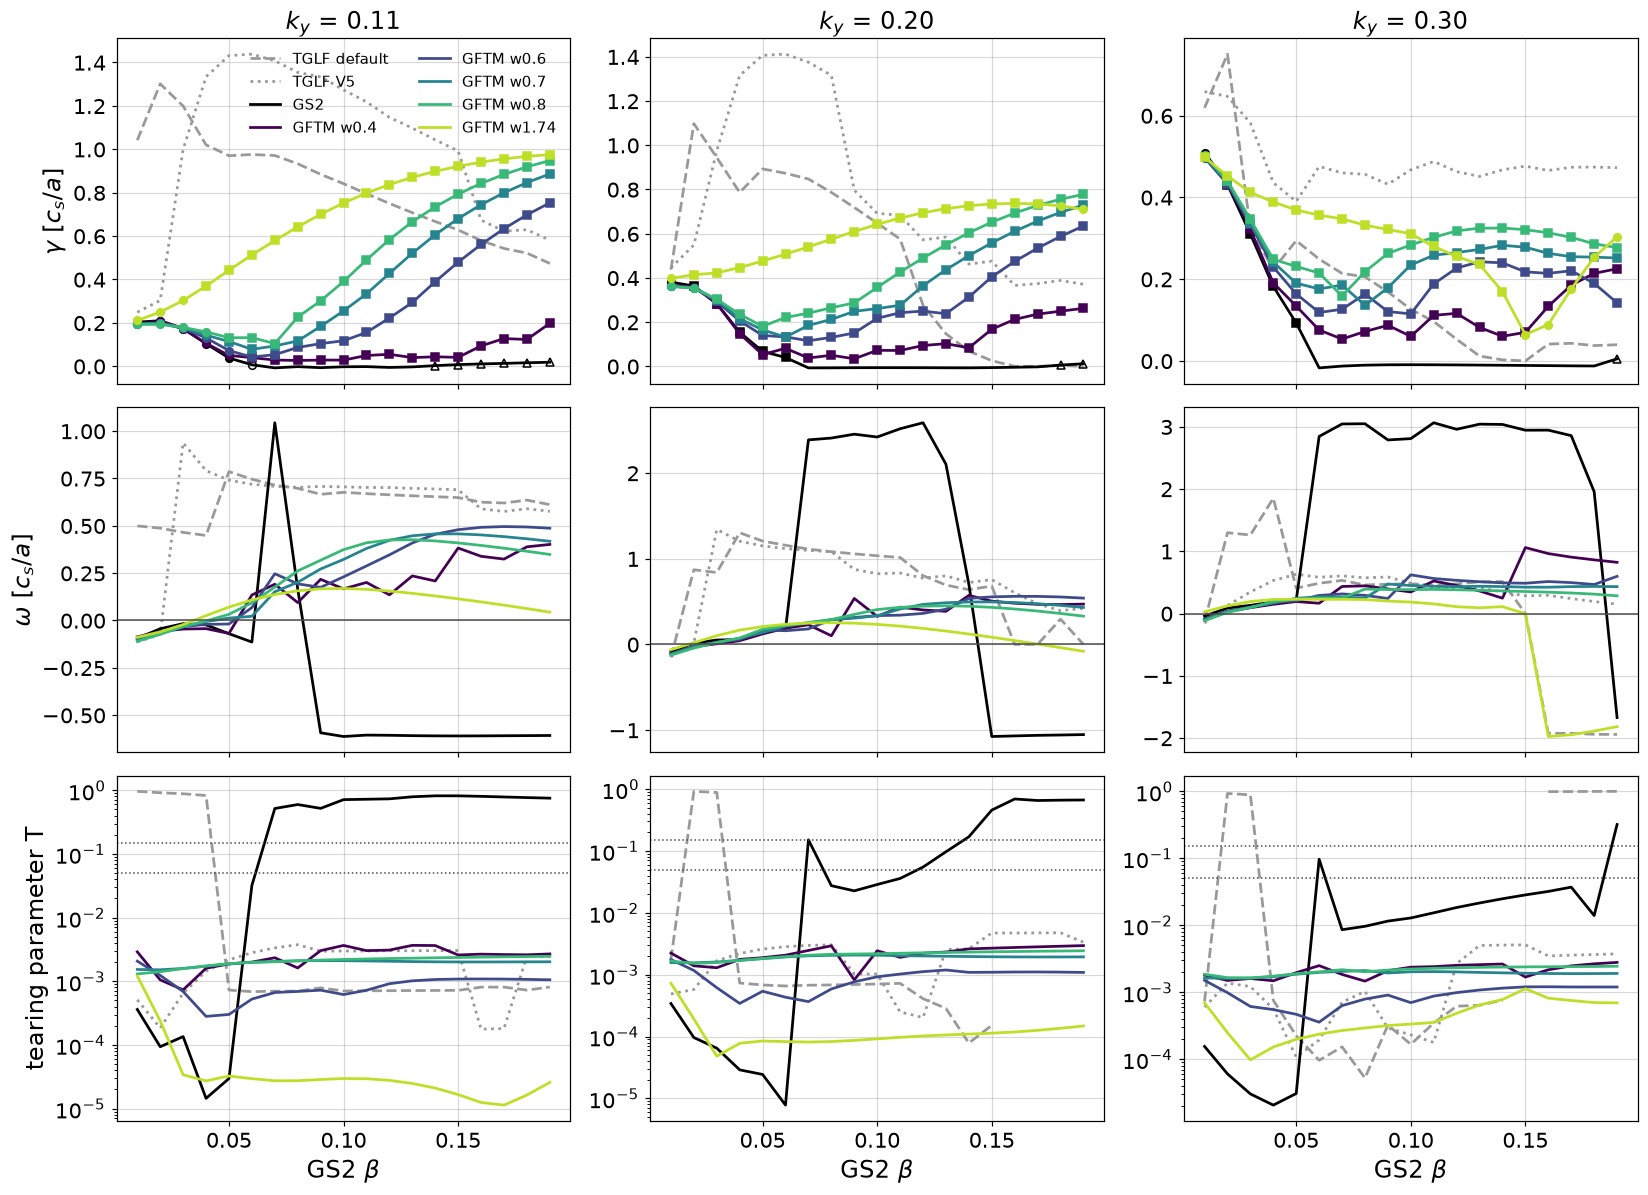

ky 0.112 GS2         m m m m m m - - - - - - - M M M M M M
ky 0.112 GFTM w0.4   m m m m m K K K K K K K K K K K K K K
ky 0.112 GFTM w0.6   m m m m m K K K K K K K K K K K K K K
ky 0.112 GFTM w0.7   m m m m K K K K K K K K K K K K K K K
ky 0.112 GFTM w0.8   m m m m K K K K K K K K K K K K K K K
ky 0.112 GFTM w1.74  m m m K K K K K K K K K K K K K K K K
ky 0.200 GS2         m K K K K K - - - - - - - - - - - M M
ky 0.200 GFTM w0.4   m m K K K K K K K K K K K K K K K K K
ky 0.200 GFTM w0.6   m m K K K K K K K K K K K K K K K K K
ky 0.200 GFTM w0.7   m m K K K K K K K K K K K K K K K K K
ky 0.200 GFTM w0.8   m m K K K K K K K K K K K K K K K K K
ky 0.200 GFTM w1.74  m K K K K K K K K K K K K K K K K m m
ky 0.300 GS2         m K K K K - - - - - - - - - - - - - M
ky 0.300 GFTM w0.4   m K K K K K K K K K K K K K K K K K K
ky 0.300 GFTM w0.6   m K K K K K K K K K K K K K K K K K K
ky 0.300 GFTM w0.7   m K K K K K K K K K K K K K K K K K K
ky 0.300 GFTM w0.8   m K K K K K K K K K K K K K K K K K

In [11]:
print("cutoffs: T_BAL", mc.T_BAL, "T_TEAR", mc.T_TEAR, "CHI_KBM", mc.CHI_KBM)


def gs2_run(i, j):
    return data_root / gs2_code / run_template / gs2_project / r4 / gs2_scan / f"ky{float(gs2[r4].ky[i]):.3f}_beta{beta_r4[j]:.3f}"


gs2_ind = {}
for i in iky:
    for j in range(beta_r4.size):
        pyro = Pyro(gk_file=gs2_run(i, j) / "gs2.in")
        pyro.load_gk_output(load_fields=True, load_fluxes=True)
        gs2_ind[i, j] = mc.indicators(pyro)

code, project, leaf, _ = r4_codes["GFTM w1.74"]
T174 = np.full(R["GFTM w1.74"].growth_rate.shape, np.nan)
for i in iky:
    for j in range(beta_r4.size):
        d = data_root / code / run_template / project / r4 / leaf / f"ky{float(gs2[r4].ky[i]):.3f}_beta{beta_r4[j]:.3f}"
        pyro = Pyro(gk_file=d / "input.gftm")
        pyro.load_gk_output(load_fields=True, load_fluxes=False)
        t = np.atleast_1d(np.asarray(FieldLine(pyro).compute_linear_tearing_parameter()).squeeze())
        T174[i, j, :t.size] = t
R["GFTM w1.74"]["tearing_parameter"] = (("ky", "beta", "mode"), T174)

w = {lab: v(dominant(d, "mode_frequency")) for lab, d in R.items()}
T = {lab: v(dominant(d, "tearing_parameter")) for lab, d in R.items() if lab != "GS2"}
T["GS2"] = np.full(g["GS2"].shape, np.nan)
for (i, j), ind in gs2_ind.items():
    T["GS2"][i, j] = ind["T"]
label = {lab: code_type(T[lab], w[lab]) for lab in r4_codes}
label["GS2"] = {k: mc.classify(ind) for k, ind in gs2_ind.items()}
tglf = {lab: model[(r4, lab)] for lab in ("TGLF default", "TGLF V5")}
tglf_dom = {lab: ds.growth_rate.fillna(-np.inf).argmax("mode") for lab, ds in tglf.items()}

fig_gwt, axes = plt.subplots(3, len(iky), figsize=(5 * len(iky), 11), sharex=True)
for col, i in enumerate(iky):
    for lab, ls in zip(tglf, ("--", ":")):
        ds, m = tglf[lab], tglf_dom[lab]
        for row, var in enumerate(("growth_rate", "mode_frequency", "tearing_parameter")):
            axes[row, col].plot(beta_r4, ds[var].isel(mode=m).values[i], color="0.6", ls=ls, label=lab, marker="none")
    for lab in ["GS2", *r4_codes]:
        c = line_colour[lab]
        for row, y in enumerate((g[lab][i], w[lab][i], T[lab][i])):
            axes[row, col].plot(beta_r4, y, color=c, label=lab, marker="none")
        for j in range(beta_r4.size):
            if g[lab][i, j] > gamma_floor:
                t = label[lab][i, j]
                open_ = lab == "GS2" and unconv[i, j]
                axes[0, col].plot(beta_r4[j], g[lab][i, j], color=c, ls="", marker=marker[t], ms=5, mfc="none" if open_ else c)
    axes[0, col].set_title(rf"$k_y$ = {float(gs2[r4].ky[i]):.2f}", fontsize=16)
    axes[2, col].set_yscale("log")
    axes[2, col].axhline(mc.T_BAL, color="0.3", ls=":", lw=1, marker="")
    axes[2, col].axhline(mc.T_TEAR, color="0.3", ls=":", lw=1, marker="")
    axes[1, col].axhline(0, color="0.3", lw=1, marker="")
for row, yl in enumerate((r"$\gamma$ [$c_s/a$]", r"$\omega$ [$c_s/a$]", "tearing parameter T")):
    axes[row, 0].set_ylabel(yl, fontsize=16)
for ax in axes.flat:
    ax.tick_params(labelsize=14)
for ax in axes[-1]:
    ax.set_xlabel(r"GS2 $\beta$", fontsize=16)
axes[0, 0].legend(fontsize=10, ncol=2)
fig_gwt.tight_layout()
plt.show()

for i in iky:
    for lab in ["GS2", *r4_codes]:
        print(f"ky {float(gs2[r4].ky[i]):.3f} {lab:11s}", " ".join(
            f"{label[lab][i, j][0] if g[lab][i, j] > 0 else '-'}" for j in range(beta_r4.size)))

### (4) GS2 trust: convergence per cell and γ(t) at the eigenfunction cells

`growth_rate_tolerance` per plotted cell (tol < 1e-2 converged, ≥ 1e-1 unconverged), then GS2's own γ(t) at the three
eigenfunction cells, with the GFTM γ at the same cell as horizontal lines. A mode growing at γ for the GS2 run time
t_end would have grown by exp(γ t_end); that number is printed.

        0.11    0.2     0.3 
0.01 6.7e-05 5.3e-05 7.9e-06
0.02 3.6e-05 5.9e-05 1.4e-05
0.03  0.0018 0.00028 3.9e-05
0.04 0.00041 0.00027 8.6e-05
0.05 0.00092  0.0031 0.00034
0.06     2.4  0.0005     1.2
0.07     1.1     1.1    0.21
0.08     1.1    0.73    0.25
0.09     1.1    0.64    0.19
0.1      1.9    0.57    0.06
0.11     1.1    0.57   0.053
0.12     1.2    0.67   0.018
0.13     1.1    0.82   0.034
0.14     1.2    0.83   0.016
0.15     1.6     1.1   0.017
0.16     1.9     1.1   0.015
0.17     3.1     1.1   0.022
0.18     2.5     1.8   1e+02
0.19     0.3    0.73     1.5
ky 0.112 beta>=0.07: converged 0, marginal 0, unconverged 13 of 13; max |gamma_GS2| 0.018
ky 0.200 beta>=0.07: converged 0, marginal 0, unconverged 13 of 13; max |gamma_GS2| 0.012
ky 0.300 beta>=0.07: converged 0, marginal 8, unconverged 5 of 13; max |gamma_GS2| 0.013


control: GFTM w0.4 gamma 0.360, t_end 24, gamma*t_end 9
control: GFTM w0.8 gamma 0.354, t_end 24, gamma*t_end 9
control: GFTM w1.74 gamma 0.414, t_end 24, gamma*t_end 10


high, ky 0.11: GFTM w0.4 gamma 0.041, t_end 341, gamma*t_end 14
high, ky 0.11: GFTM w0.8 gamma 0.793, t_end 341, gamma*t_end 271
high, ky 0.11: GFTM w1.74 gamma 0.921, t_end 341, gamma*t_end 314


high, ky 0.2: GFTM w0.4 gamma 0.168, t_end 341, gamma*t_end 57
high, ky 0.2: GFTM w0.8 gamma 0.652, t_end 341, gamma*t_end 222
high, ky 0.2: GFTM w1.74 gamma 0.734, t_end 341, gamma*t_end 251


/tmp/ipykernel_100698/3577424000.py:26: UserWarning: The figure layout has changed to tight
  fig_gt.tight_layout()


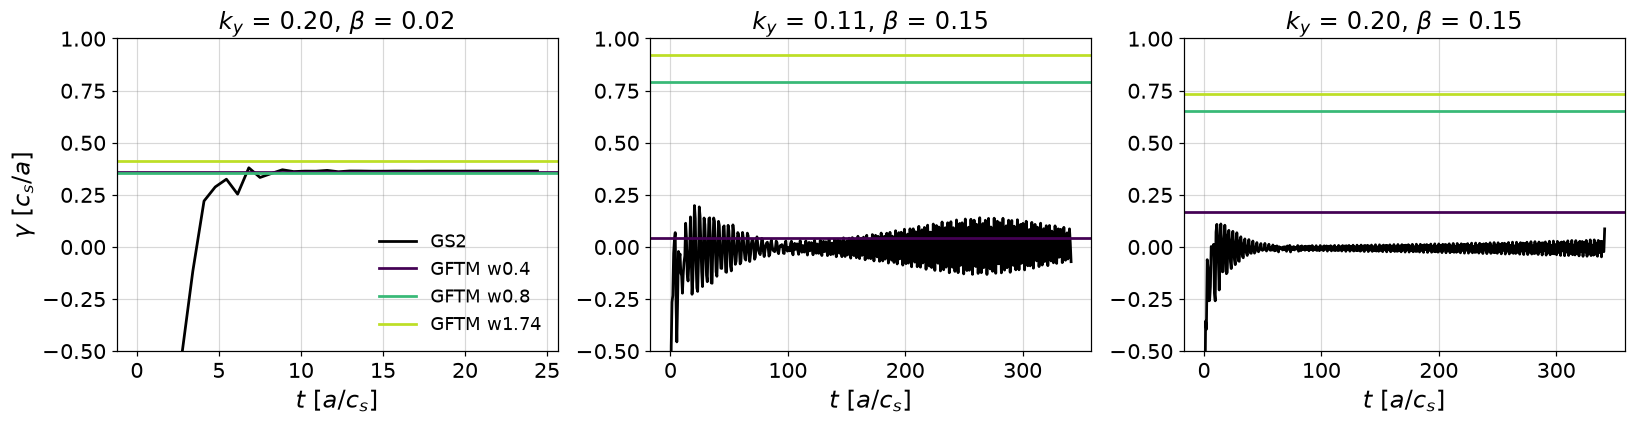

In [12]:
tol_table = pd.DataFrame(tol[iky].T, index=beta_r4.round(2), columns=[round(float(gs2[r4].ky[i]), 3) for i in iky])
with pd.option_context("display.float_format", "{:.2g}".format):
    print(tol_table)
for i in iky:
    hi = beta_r4 >= 0.07
    print(f"ky {float(gs2[r4].ky[i]):.3f} beta>=0.07: converged {(tol[i, hi] < 1e-2).sum()}, marginal "
          f"{((tol[i, hi] >= 1e-2) & (tol[i, hi] < 1e-1)).sum()}, unconverged {(tol[i, hi] >= 1e-1).sum()} of {hi.sum()}; "
          f"max |gamma_GS2| {np.abs(g['GS2'][i, hi]).max():.3f}")

fig_gt, axes = plt.subplots(1, len(cells), figsize=(5 * len(cells), 4))
for ax, (name, (i, j)) in zip(axes, cells.items()):
    pyro = Pyro(gk_file=gs2_run(i, j) / "gs2.in")
    pyro.load_gk_output(load_fields=True, load_fluxes=False)
    gt = pyro.gk_output["growth_rate"].squeeze()
    t = v(gt.time)
    ax.plot(t, v(gt), color="k", label="GS2", marker="none")
    for lab in ("GFTM w0.4", "GFTM w0.8", "GFTM w1.74"):
        ax.axhline(g[lab][i, j], color=colour[lab], label=lab, marker="")
        print(f"{name}: {lab} gamma {g[lab][i, j]:.3f}, t_end {t[-1]:.0f}, gamma*t_end {g[lab][i, j] * t[-1]:.0f}")
    ax.set_title(rf"$k_y$ = {float(gs2[r4].ky[i]):.2f}, $\beta$ = {beta_r4[j]:.2f}", fontsize=16)
    ax.set_xlabel(r"$t$ [$a/c_s$]", fontsize=16)
    ax.tick_params(labelsize=14)
    ax.set_ylim(-0.5, 1.0)
axes[0].set_ylabel(r"$\gamma$ [$c_s/a$]", fontsize=16)
axes[0].legend(fontsize=12)
fig_gt.tight_layout()
plt.show()

### (5) WIDTH dependence at fixed high β

Dominant GFTM γ and log(Extent Ratio) of φ against WIDTH at β = 0.15 (GS2 number), one line per ky; GS2's γ at the
same cell dotted in the same colour.

/tmp/ipykernel_100698/2422550590.py:23: UserWarning: The figure layout has changed to tight
  fig_w.tight_layout()


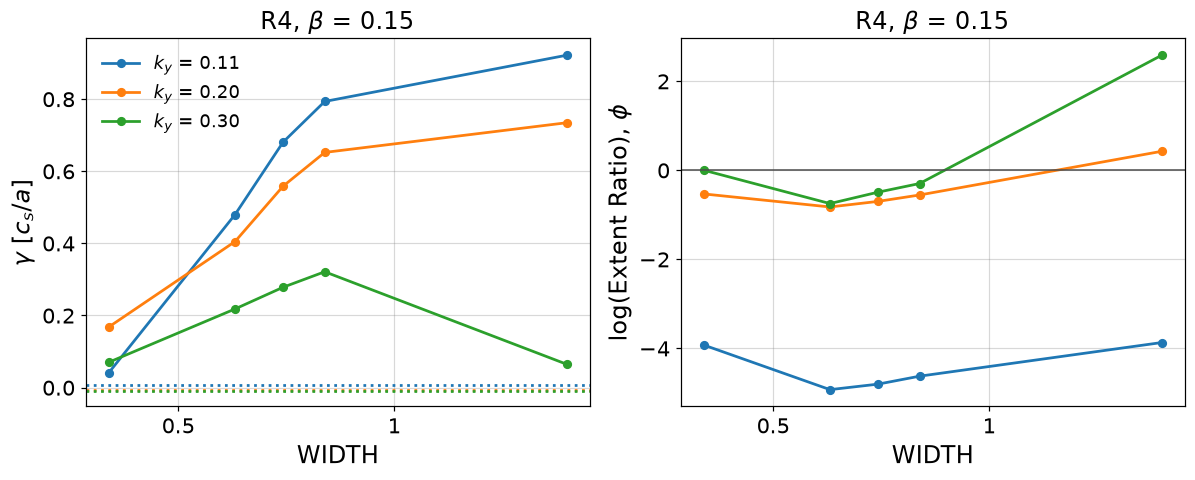

ky 0.112 beta 0.15: GS2 gamma +0.007 | W0.4 +0.041  W0.6 +0.480  W0.7 +0.680  W0.8 +0.793  W1.74 +0.921
ky 0.200 beta 0.15: GS2 gamma -0.006 | W0.4 +0.168  W0.6 +0.405  W0.7 +0.558  W0.8 +0.652  W1.74 +0.734
ky 0.300 beta 0.15: GS2 gamma -0.011 | W0.4 +0.070  W0.6 +0.218  W0.7 +0.278  W0.8 +0.321  W1.74 +0.064


In [13]:
widths = np.array([spec[3] for spec in r4_codes.values()])
fig_w, (ax_g, ax_e) = plt.subplots(1, 2, figsize=(11, 4.5))
for c, i in enumerate(iky):
    ky_lab = rf"$k_y$ = {float(gs2[r4].ky[i]):.2f}"
    ax_g.plot(widths, [g[lab][i, jhi] for lab in r4_codes], color=f"C{c}", marker="o", ms=5, label=ky_lab)
    ax_g.axhline(g["GS2"][i, jhi], color=f"C{c}", ls=":", marker="")
    ax_e.plot(widths, [np.log2(ext[lab]["phi"][i, jhi] / ext["GS2"]["phi"][i, jhi]) for lab in r4_codes],
              color=f"C{c}", marker="o", ms=5, label=ky_lab)
ax_e.axhline(0, color="0.3", lw=1, marker="")
ax_g.set_ylabel(r"$\gamma$ [$c_s/a$]", fontsize=16)
ax_e.set_ylabel(r"log(Extent Ratio), $\phi$", fontsize=16)
for ax in (ax_g, ax_e):
    ax.set_xscale("log")
    lims = ax.get_xlim()
    ax.set_xticks([0.5, 1, 2, 5, 10])
    ax.set_xlim(lims)
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:g}"))
    ax.minorticks_off()
    ax.set_xlabel("WIDTH", fontsize=16)
    ax.set_title(rf"R4, $\beta$ = {beta_r4[jhi]:.2f}", fontsize=16)
    ax.tick_params(labelsize=14)
ax_g.legend(fontsize=12)
fig_w.tight_layout()
plt.show()
for i in iky:
    print(f"ky {float(gs2[r4].ky[i]):.3f} beta {beta_r4[jhi]:.2f}: GS2 gamma {g['GS2'][i, jhi]:+.3f} | " +
          "  ".join(f"W{wd:g} {g[lab][i, jhi]:+.3f}" for wd, lab in zip(widths, r4_codes)))

### β′ and field consistency at the high-β cell

Same cell read by both codes' own decks through pyro, in pyrokinetics normalisation: β, β′, q, ŝ and the field
switches. If these differ, GFTM is not being asked the same question as GS2.

In [14]:
i, j = cells["high, ky 0.2"]
code, project, leaf, _ = r4_codes["GFTM w1.74"]
decks = {"GS2": gs2_run(i, j) / "gs2.in",
         "GFTM w1.74": data_root / code / run_template / project / r4 / leaf / f"ky{float(gs2[r4].ky[i]):.3f}_beta{beta_r4[j]:.3f}" / "input.gftm"}
for lab, path in decks.items():
    p = Pyro(gk_file=path)
    lg, nu = p.local_geometry, p.numerics
    print(f"{lab:10s} beta {nu.beta.to(p.norms.pyrokinetics).m:.6f}  beta' {lg.beta_prime.to(p.norms.pyrokinetics).m:.6f}  "
          f"q {lg.q.m:.4f}  shat {lg.shat.m:.4f}  phi {nu.phi} apar {nu.apar} bpar {nu.bpar}")

r4_figs = {"R4_eigenfunctions": fig_eig, "R4_eigenfunction_phase": fig_ph, "R4_extent_vs_beta": fig_ext,
           "R4_extent_ratio_vs_beta": fig_rat, "R4_gamma_omega_T_vs_beta": fig_gwt, "R4_gs2_gamma_t": fig_gt,
           "R4_gamma_extent_vs_width": fig_w}
for name, fig in r4_figs.items():
    fig.savefig(output_dir / f"{name}.png", dpi=150, bbox_inches="tight")
print("saved", len(r4_figs), "R4 figures to", output_dir)

GS2        beta 0.131640  beta' -2.055328  q 5.3076  shat 1.9661  phi True apar True bpar True


GFTM w1.74 beta 0.131640  beta' -2.055328  q 5.3076  shat 1.9661  phi True apar True bpar True


saved 7 R4 figures to /pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_3d61/Plots/beta_stabilisation_f05


### (6.1) Ideal-ballooning stability of R4 vs β (follow-up 1, approved by the user 2026-10-02)

pyro `Diagnostics.ideal_ballooning_solver` at θ0 = 0, on GS2's own R4 decks (one per β; ideal MHD is ky-independent,
so the ky 0.2 decks are used), at each deck's own numerics and at nperiod 5 / ntheta 64 (the setting earlier s-α
work used). Only the **sign** of γ_ideal is meaningful: for a stable case |γ| shrinks as the ballooning domain grows.
x axis α = q² (R/a) |β′| with β′ in pyrokinetics normalisation.

**Positive control:** the M1_A1 GS2 template (`$GYRO_DATA_INPUT/GS2/Templates/M1_A1`), where Fusion_PhD-52l found
an ideal-unstable band α ≈ 4.4–11.8, with β′ scaled to each α (geometry otherwise fixed), and R4's β = 0.15 deck
scaled the same way to extend its α range down to 0.5.

R4 alpha over the GS2 beta grid: [  7.3  14.7  22.   29.3  36.6  44.   51.3  58.6  66.   73.3  80.6  87.9
  95.3 102.6 109.9 117.2 124.6 131.9 139.2]
R4 decks, deck: unstable (gamma_ideal > 0) in 0 of 19
R4 decks, nperiod 5, ntheta 64: unstable (gamma_ideal > 0) in 0 of 19
M1_A1 (control): unstable alpha [ 5.  6.  8. 10.]
R4, β′ scaled: unstable alpha []


/tmp/ipykernel_100698/868840457.py:54: UserWarning: The figure layout has changed to tight
  fig_ib.tight_layout()


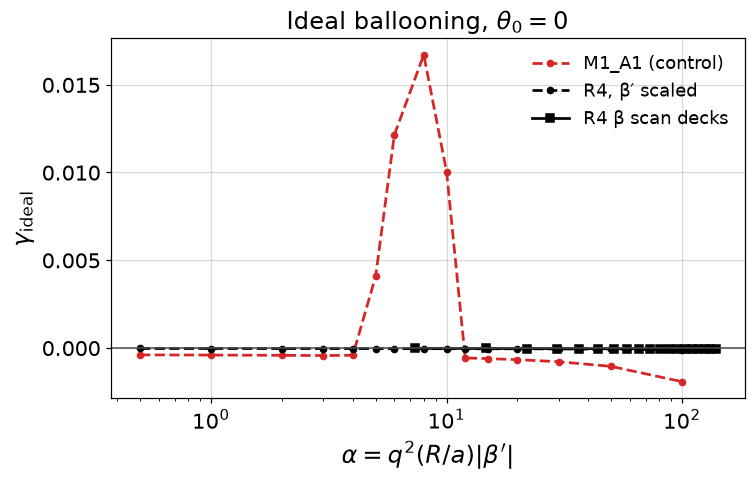

In [15]:
from pyrokinetics.diagnostics import Diagnostics


def alpha_of(p):
    lg = p.local_geometry
    return float(lg.q.m ** 2 * lg.Rmaj.m * abs(lg.beta_prime.to(p.norms.pyrokinetics).m))


def ideal(p, nperiod=None, ntheta=None):
    if nperiod:
        p.numerics.nperiod, p.numerics.ntheta = nperiod, ntheta
    return float(Diagnostics(p).ideal_ballooning_solver(theta0=0.0))


ideal_numerics = {"deck": (None, None), "nperiod 5, ntheta 64": (5, 64)}
alpha_r4, g_ideal_r4 = np.zeros(beta_r4.size), {k: np.zeros(beta_r4.size) for k in ideal_numerics}
for j in range(beta_r4.size):
    for k, (nper, nth) in ideal_numerics.items():
        p = Pyro(gk_file=gs2_run(iky[1], j) / "gs2.in")
        alpha_r4[j] = alpha_of(p)
        g_ideal_r4[k][j] = ideal(p, nper, nth)

alpha_scan = np.array([0.5, 1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 30, 50, 100])
control = {"M1_A1 (control)": Path(os.environ["GYRO_DATA_INPUT"]) / "GS2/Templates/M1_A1/gs2.in",
           "R4, β′ scaled": gs2_run(iky[1], jhi) / "gs2.in"}
g_scan = {}
for name, deck in control.items():
    p = Pyro(gk_file=deck, gk_code="GS2")
    bp0, a0 = p.local_geometry.beta_prime, alpha_of(p)
    p.numerics.nperiod, p.numerics.ntheta = 5, 64
    g_scan[name] = []
    for a in alpha_scan:
        p.local_geometry.beta_prime = bp0 * (a / a0)
        g_scan[name].append(ideal(p))

print("R4 alpha over the GS2 beta grid:", alpha_r4.round(1))
for k, gi in g_ideal_r4.items():
    print(f"R4 decks, {k}: unstable (gamma_ideal > 0) in {(gi > 0).sum()} of {gi.size}")
for name, gi in g_scan.items():
    gi = np.array(gi)
    print(f"{name}: unstable alpha", alpha_scan[gi > 0])

fig_ib, ax = plt.subplots(figsize=(7, 4.5))
for (name, gi), c in zip(g_scan.items(), ("C3", "k")):
    ax.plot(alpha_scan, gi, color=c, ls="--", marker="o", ms=4, label=name)
ax.plot(alpha_r4, g_ideal_r4["deck"], color="k", marker="s", ms=5, label="R4 β scan decks")
ax.axhline(0, color="0.3", lw=1, marker="")
ax.set_xscale("log")
ax.set_xlabel(r"$\alpha = q^2 (R/a) |\beta'|$", fontsize=16)
ax.set_ylabel(r"$\gamma_{\rm ideal}$", fontsize=16)
ax.set_title(r"Ideal ballooning, $\theta_0 = 0$", fontsize=16)
ax.tick_params(labelsize=14)
ax.legend(fontsize=12)
fig_ib.tight_layout()
plt.show()
fig_ib.savefig(output_dir / "R4_ideal_ballooning.png", dpi=150, bbox_inches="tight")

### A∥ vs β per WIDTH (user request 2026-10-02)

Dominant mode. Top: pyro `Extent` of A∥ (95% of ∫|A∥|²dθ). Bottom: peak |A∥| / peak |φ| of the same eigenfunction,
both codes in pyro's normalisation. GS2 open = unconverged (tol ≥ 0.1).

/tmp/ipykernel_100698/4157849195.py:3: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.abs(v(e.sel(field="apar"))), axis=-1) / np.nanmax(np.abs(v(e.sel(field="phi"))), axis=-1)


/tmp/ipykernel_100698/4157849195.py:24: UserWarning: The figure layout has changed to tight
  fig_apar.tight_layout()


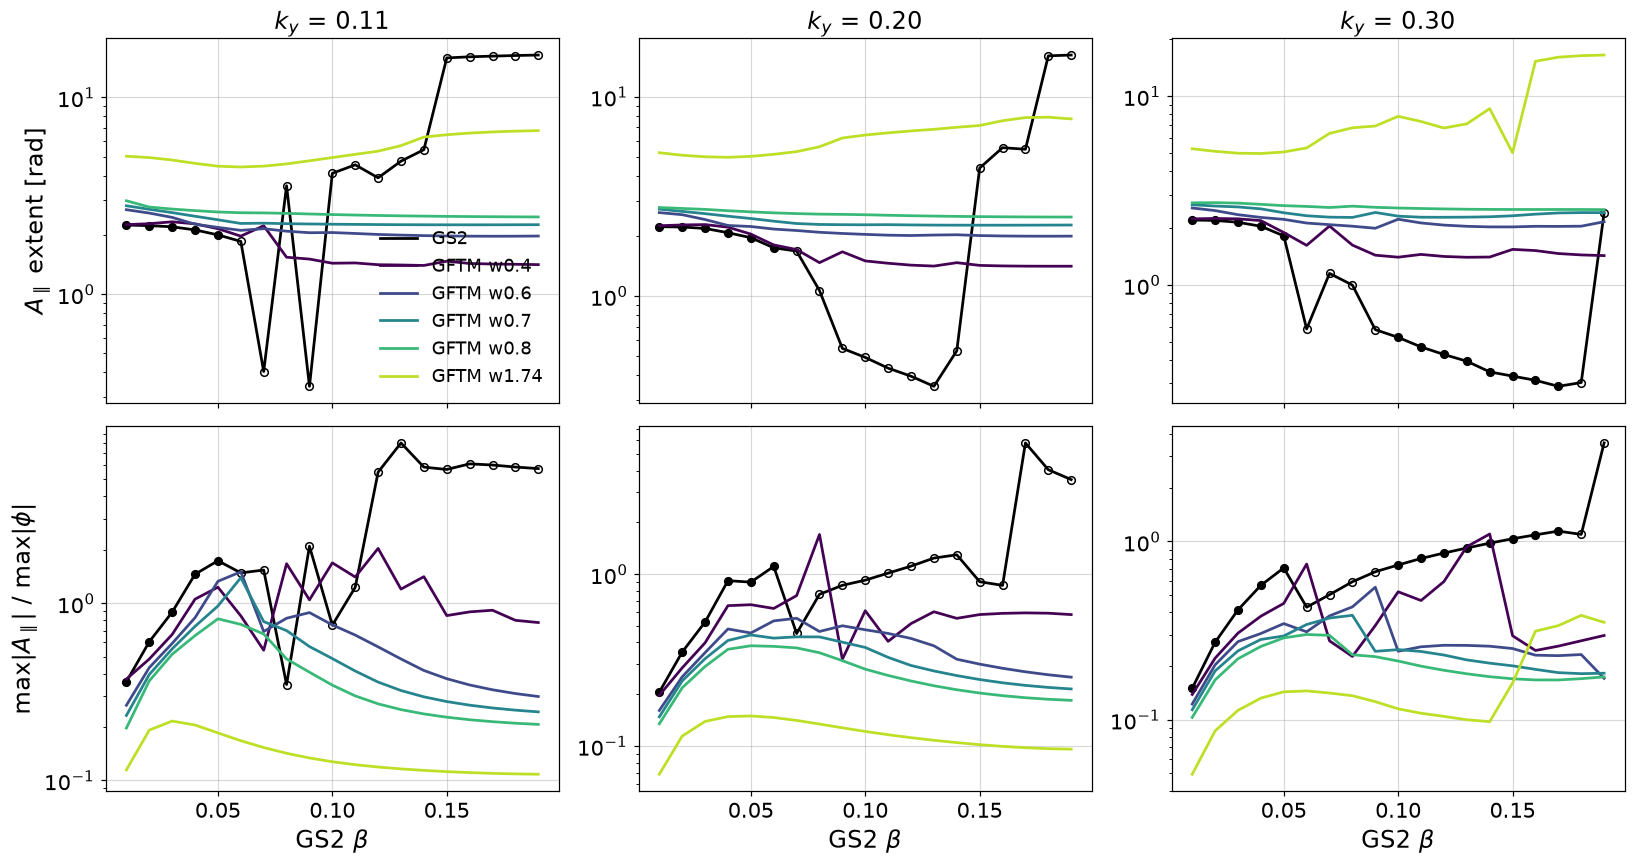

ky 0.112 beta 0.02  Apar extent / ratio: GS2 2.23/0.61  w0.4 2.28/0.48  w0.6 2.58/0.43  w0.7 2.70/0.40  w0.8 2.77/0.36  w1.74 4.94/0.19
ky 0.112 beta 0.15  Apar extent / ratio: GS2 15.86/5.68  w0.4 1.47/0.85  w0.6 1.97/0.37  w0.7 2.25/0.28  w0.8 2.48/0.23  w1.74 6.45/0.11
ky 0.200 beta 0.02  Apar extent / ratio: GS2 2.21/0.35  w0.4 2.27/0.28  w0.6 2.55/0.25  w0.7 2.65/0.24  w0.8 2.74/0.22  w1.74 5.08/0.11
ky 0.200 beta 0.15  Apar extent / ratio: GS2 4.38/0.90  w0.4 1.42/0.58  w0.6 2.01/0.30  w0.7 2.26/0.24  w0.8 2.50/0.20  w1.74 7.16/0.10
ky 0.300 beta 0.02  Apar extent / ratio: GS2 2.19/0.27  w0.4 2.25/0.22  w0.6 2.47/0.20  w0.7 2.61/0.19  w0.8 2.72/0.17  w1.74 5.10/0.09
ky 0.300 beta 0.15  Apar extent / ratio: GS2 0.33/1.03  w0.4 1.54/0.30  w0.6 2.03/0.25  w0.7 2.32/0.20  w0.8 2.51/0.17  w1.74 5.01/0.16


In [16]:
def apar_ratio(d):
    e = dominant(d, "eigenfunctions")
    return np.nanmax(np.abs(v(e.sel(field="apar"))), axis=-1) / np.nanmax(np.abs(v(e.sel(field="phi"))), axis=-1)


ratio = {lab: apar_ratio(d) for lab, d in R.items()}
fig_apar, axes = plt.subplots(2, len(iky), figsize=(5 * len(iky), 8), sharex=True)
for col, i in enumerate(iky):
    for row, y in enumerate((ext, ratio)):
        ax = axes[row, col]
        yy = {lab: (y[lab]["apar"] if row == 0 else y[lab])[i] for lab in R}
        ax.plot(beta_r4, yy["GS2"], color="k", label="GS2", marker="none")
        ax.plot(beta_r4[~unconv[i]], yy["GS2"][~unconv[i]], color="k", ls="", marker="o", ms=5)
        ax.plot(beta_r4[unconv[i]], yy["GS2"][unconv[i]], color="k", ls="", marker="o", ms=5, mfc="none")
        for lab in r4_codes:
            ax.plot(beta_r4, yy[lab], color=colour[lab], label=lab, marker="none")
        ax.set_yscale("log")
        ax.tick_params(labelsize=14)
    axes[0, col].set_title(rf"$k_y$ = {float(gs2[r4].ky[i]):.2f}", fontsize=16)
    axes[1, col].set_xlabel(r"GS2 $\beta$", fontsize=16)
axes[0, 0].set_ylabel(r"$A_\parallel$ extent [rad]", fontsize=16)
axes[1, 0].set_ylabel(r"max$|A_\parallel|$ / max$|\phi|$", fontsize=16)
axes[0, 0].legend(fontsize=12)
fig_apar.tight_layout()
plt.show()
fig_apar.savefig(output_dir / "R4_apar_vs_beta.png", dpi=150, bbox_inches="tight")
for i in iky:
    for j in (jlo, jhi):
        print(f"ky {float(gs2[r4].ky[i]):.3f} beta {beta_r4[j]:.2f}  Apar extent / ratio: " + "  ".join(
            f"{lab.replace('GFTM ', '')} {ext[lab]['apar'][i, j]:.2f}/{ratio[lab][i, j]:.2f}" for lab in R))